# Potomac Plume Context — Tutorial: From Discharge Anomaly to AOI Footprint

A practitioner-facing tutorial for translating the corridor's discharge signal into a *spatially scoped* plume-tracking framework. Combines the dataset's daily discharge, the operational event log, and the four AOI corridor polygons (spill site → DC tidal → lower Potomac → upper Bay) into a phase-aware plume context.

This notebook ships with two paths:

1. **Executable spatial framework (this notebook).** Loads gauges, AOI bboxes, and discharge; maps the corridor; assigns gauges to AOIs; and walks through the phase-dependent "which AOI is in scope" logic. No GPU required.
2. **Recipe for OlmoEarth-based plume detection.** Documented but not executed here, since real plume detection requires Sentinel-1 / Sentinel-2 imagery + OlmoEarth encoder forward passes (GPU). The code-path shows how to swap from anomaly-from-discharge to anomaly-from-embedding-distance over each AOI.

## What You'll Learn

- The four AOI corridor polygons and how they partition the spill's downstream flow path
- Which USGS gauges anchor each AOI (containment check)
- A phase-aware "plume scope" table: which AOI is operationally in play at each phase of the event
- How to use the upstream-vs-near-spill discharge ratio (from `01`/`04`) as a coarse proxy for plume activity at the spill_site_zone AOI
- A recipe for upgrading from discharge-only signals to OlmoEarth Sentinel-1/2 embedding-distance signals per AOI

## Why

Discharge tells you *how much*; AOI polygons tell you *where*. For incident response, TMDL accounting, or downstream-impact assessment, both are required. A pure flow signal can't say whether the plume reached the upper Bay receiving zone; a pure satellite signal without flow context can't distinguish ambient turbidity from event-driven discharge.

## Requirements

- Python 3.11
- `pandas`, `numpy`, `matplotlib`, `datasets`, `huggingface_hub` (see `requirements.txt`)
- ~1 minute runtime, no GPU
- For the OlmoEarth-embedding upgrade path (Section 5): GPU + Sentinel-1/2 access (e.g., Planetary Computer)

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle, Patch
from datasets import load_dataset
from huggingface_hub import hf_hub_download

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

PHASE_ORDER = ['pre_spill_baseline', 'active_release', 'bypass_period', 'post_recovery']

PHASE_COLORS = {
    'pre_spill_baseline': '#cfd8dc',
    'active_release':     '#ef5350',
    'bypass_period':      '#ffb74d',
    'post_recovery':      '#aed581',
}

# AOI corridor polygons (bbox: lon_min, lat_min, lon_max, lat_max).
# Source: dataset metadata. Same as the polygons in spill_metadata.geojson.
AOI_CORRIDORS = {
    'spill_site_zone': {
        'bbox': (-77.20, 38.94, -77.08, 39.00),
        'color': '#c62828',
        'description': 'Glen Echo / Little Falls vicinity (spill location)',
    },
    'tidal_potomac_dc': {
        'bbox': (-77.20, 38.78, -77.00, 38.98),
        'color': '#ef6c00',
        'description': 'DC reach of the Potomac',
    },
    'tidal_potomac_lower': {
        'bbox': (-77.10, 38.00, -76.30, 38.78),
        'color': '#fbc02d',
        'description': 'Lower tidal Potomac toward the mouth',
    },
    'upper_chesapeake_bay': {
        'bbox': (-76.50, 37.80, -76.00, 38.40),
        'color': '#43a047',
        'description': 'Upper Bay receiving zone',
    },
}

SPILL_SITE = (38.9676, -77.1437)  # (lat, lon)

## 1. Load discharge + event log

Standard pulls from Hugging Face. The discharge frame anchors gauge positions; the event log anchors phase-by-phase reporting density.

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026")
df = ds["train"].to_pandas()
df['date'] = pd.to_datetime(df['date'])

event_log_path = hf_hub_download(
    repo_id="BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026",
    filename="event_log.csv",
    repo_type="dataset",
)
events = pd.read_csv(event_log_path, parse_dates=['date'])

stations = (
    df.drop_duplicates('site_no')[['site_no', 'name', 'role', 'latitude', 'longitude']]
      .reset_index(drop=True)
)
print(f"Stations: {len(stations)}  |  Discharge rows: {len(df):,}  |  Events: {len(events)}")

'[WinError 10054] An existing connection was forcibly closed by the remote host' thrown while requesting HEAD https://huggingface.co/datasets/BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026/resolve/224bf3f9b03a2f5d8c90f11d99347989f393c58f/OlmoEarth-v1-Potomac-Sewage-Spill-2026.py


Retrying in 1s [Retry 1/5].


Using the latest cached version of the dataset since BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026 couldn't be found on the Hugging Face Hub


Found the latest cached dataset configuration 'default' at C:\Users\Frank\.cache\huggingface\datasets\BAIGroup___olmo_earth-v1-potomac-sewage-spill-2026\default\0.0.0\224bf3f9b03a2f5d8c90f11d99347989f393c58f (last modified on Sun May  3 18:46:34 2026).


Stations: 7  |  Discharge rows: 846  |  Events: 71


## 2. Map: corridor + gauges + spill site

Plot the four AOI bboxes, the eight gauges (color-coded by role), and the spill site marker. The spatial picture clarifies the dispersion path: spill at the head of the corridor flows downstream through the DC reach and the lower Potomac into the upper Bay.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


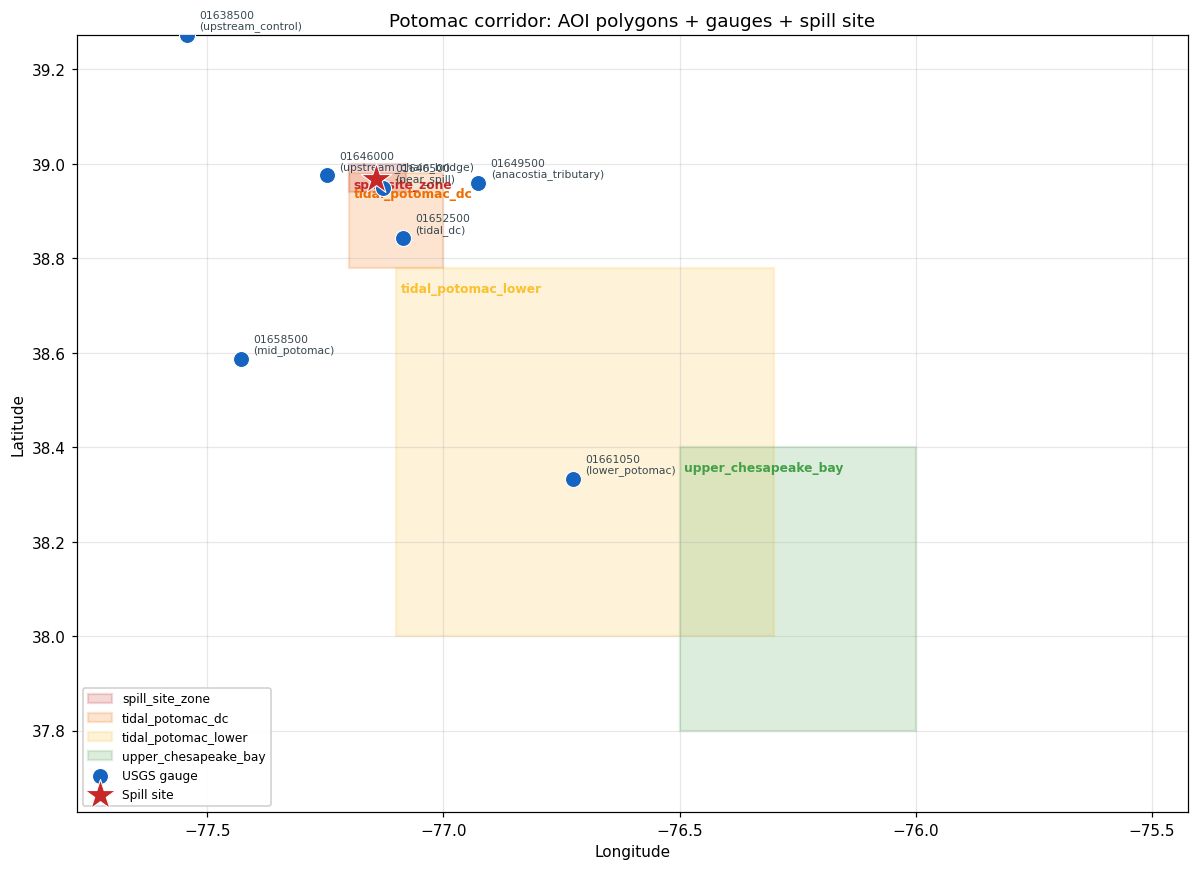

In [3]:
fig, ax = plt.subplots(figsize=(11, 8))

# AOI rectangles
for name, props in AOI_CORRIDORS.items():
    lo, la, hi, ha = props['bbox']
    rect = Rectangle((lo, la), hi - lo, ha - la,
                     facecolor=props['color'], edgecolor=props['color'],
                     alpha=0.18, linewidth=1.5, label=name)
    ax.add_patch(rect)
    # Label at top-left of each AOI
    ax.text(lo + 0.01, ha - 0.03, name, fontsize=8, color=props['color'],
            weight='bold', va='top')

# Gauges
ax.scatter(stations['longitude'], stations['latitude'],
           s=110, color='#1565c0', edgecolor='white', linewidth=0.7, zorder=3,
           label='USGS gauge')
for _, r in stations.iterrows():
    ax.annotate(f"{r['site_no']}\n({r['role']})",
                (r['longitude'], r['latitude']),
                xytext=(8, 4), textcoords='offset points', fontsize=7,
                color='#37474f', linespacing=1.05)

# Spill site marker
ax.scatter([SPILL_SITE[1]], [SPILL_SITE[0]], marker='*', s=440,
           color='#c62828', edgecolor='white', linewidth=0.7, zorder=4,
           label='Spill site')

ax.set_xlim(-77.5, -75.7)
ax.set_ylim(37.6, 39.3)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Potomac corridor: AOI polygons + gauges + spill site")
ax.legend(loc='lower left', fontsize=8, framealpha=0.95)
ax.grid(alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.show()

## 3. Anchor mapping: which gauges live in which AOI?

Bbox-containment check: for each AOI rectangle, list the gauges whose `(lon, lat)` falls inside. A gauge inside an AOI is the natural *flow anchor* for that AOI — its discharge time series is the most direct signal of what's transiting the AOI.

In [4]:
def gauges_in_bbox(stations, bbox):
    lo, la, hi, ha = bbox
    mask = ((stations['longitude'] >= lo) & (stations['longitude'] <= hi) &
            (stations['latitude']  >= la) & (stations['latitude']  <= ha))
    return stations.loc[mask, ['site_no', 'role', 'name']].to_dict('records')

anchor_map = {}
for name, props in AOI_CORRIDORS.items():
    anchors = gauges_in_bbox(stations, props['bbox'])
    anchor_map[name] = anchors
    print(f"\n{name}: {props['description']}")
    if anchors:
        for a in anchors:
            print(f"  - {a['site_no']}  ({a['role']})  {a['name'] if isinstance(a['name'], str) else ''}")
    else:
        print(f"  (no gauges within bbox)")


spill_site_zone: Glen Echo / Little Falls vicinity (spill location)
  - 01646500  (near_spill)  Potomac River near Washington, DC, Little Falls Pump Station

tidal_potomac_dc: DC reach of the Potomac
  - 01646500  (near_spill)  Potomac River near Washington, DC, Little Falls Pump Station
  - 01652500  (tidal_dc)  Potomac River at Wisconsin Ave., Washington, DC

tidal_potomac_lower: Lower tidal Potomac toward the mouth
  - 01661050  (lower_potomac)  St. Clements Creek near Clements, MD

upper_chesapeake_bay: Upper Bay receiving zone
  (no gauges within bbox)


## 4. Phase-aware plume scope

The plume develops over time. Each AOI becomes operationally "in scope" at a different phase based on travel time and dispersion. The table below is an *operational* scoping rubric — not a hydrodynamic model — but it's the right level of structure for triage and for selecting which AOIs to image with Sentinel-1/2 in each phase.

| Phase | Spill site zone | Tidal DC | Lower Potomac | Upper Bay |
|---|---|---|---|---|
| `pre_spill_baseline` | reference | reference | reference | reference |
| `active_release` | **active** (peak release) | early arrival | minimal | minimal |
| `bypass_period` | **active** (sustained) | **active** (transit) | early arrival | minimal |
| `post_recovery` | recovery | recovery | recovery / mixing | possible delayed signature |

**Reading.** A cell labeled "active" or "early arrival" means the AOI is the right scope for satellite imaging or in-situ monitoring during that phase. "Reference" or "minimal" means the AOI is not yet expected to show event-driven signal. This rubric should be **calibrated** for each new event using local hydrodynamics and tidal exchange estimates — the values above are reasonable defaults for the Jan 2026 spill but are not definitive.

In [5]:
# Build a programmatic version of the phase-AOI scope table for downstream use
PLUME_SCOPE = pd.DataFrame(
    {
        'spill_site_zone':      ['reference', 'active',         'active',          'recovery'],
        'tidal_potomac_dc':     ['reference', 'early arrival',  'active',          'recovery'],
        'tidal_potomac_lower':  ['reference', 'minimal',        'early arrival',   'recovery'],
        'upper_chesapeake_bay': ['reference', 'minimal',        'minimal',         'possible delayed'],
    },
    index=PHASE_ORDER,
)
PLUME_SCOPE

,spill_site_zone,tidal_potomac_dc,tidal_potomac_lower,upper_chesapeake_bay
pre_spill_baseline,reference,reference,reference,reference
active_release,active,early arrival,minimal,minimal
bypass_period,active,active,early arrival,minimal
post_recovery,recovery,recovery,recovery,possible delayed


## 5. Discharge anomaly as a coarse plume proxy at `spill_site_zone`

The most direct corridor signal we can compute from this dataset alone is the upstream-vs-near-spill discharge ratio (from notebook `04`). For the `spill_site_zone` AOI, this ratio is a coarse but defensible proxy for "is something abnormal transiting this AOI today." It cannot resolve dispersion downstream — that's where satellite imagery + OlmoEarth come in (Section 6).

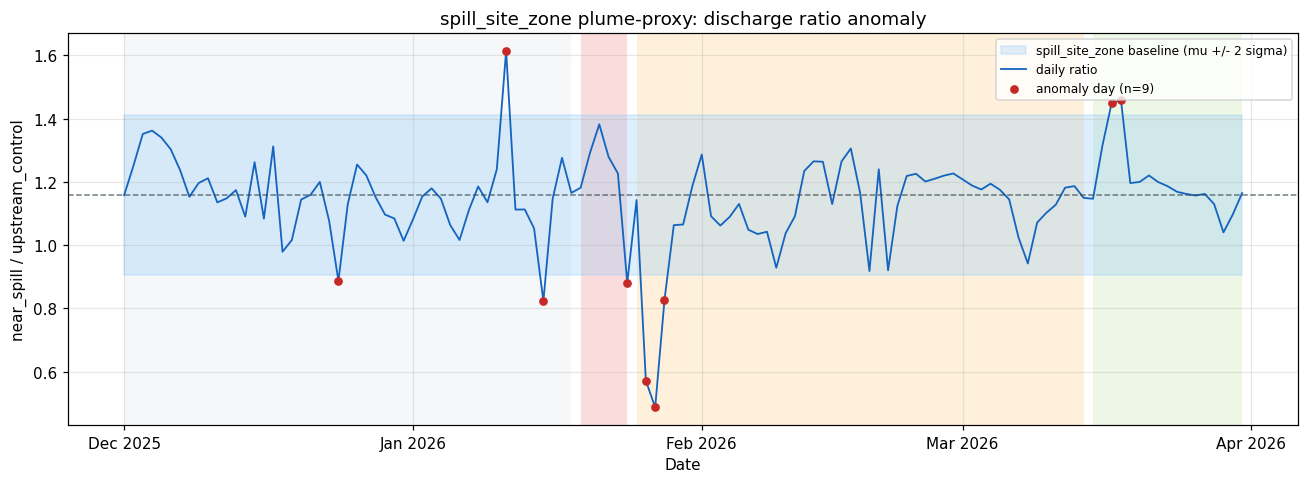


Anomaly days per phase (spill_site_zone proxy):


,spill_site_zone_anomaly_days
pre_spill_baseline,3
active_release,1
bypass_period,3
post_recovery,2


In [6]:
def gauge_series(role):
    sub = df[df['role'] == role]
    if sub.empty:
        return None, None
    sno = sub['site_no'].iloc[0]
    s = sub.sort_values('date').set_index('date')['discharge_cfs']
    return sno, s

us_sno, us = gauge_series('upstream_control')
ns_sno, ns = gauge_series('near_spill')
aligned = pd.concat([us.rename('upstream'), ns.rename('near_spill')], axis=1).dropna()
ratio = aligned['near_spill'] / aligned['upstream']

phase_dates = (
    df.groupby('phase', observed=True)['date'].agg(start='min', end='max').reindex(PHASE_ORDER)
)
baseline_mask = ((ratio.index >= phase_dates.loc['pre_spill_baseline', 'start']) &
                 (ratio.index <= phase_dates.loc['pre_spill_baseline', 'end']))
mu, sigma = ratio[baseline_mask].mean(), ratio[baseline_mask].std()

# Define spill_site_zone "plume proxy" anomaly = ratio outside baseline +/- 2 sigma
anomaly = (ratio > mu + 2 * sigma) | (ratio < mu - 2 * sigma)

fig, ax = plt.subplots(figsize=(12, 4.5))
for p in PHASE_ORDER:
    a, b = phase_dates.loc[p, ['start', 'end']]
    ax.axvspan(a, b, color=PHASE_COLORS[p], alpha=0.20, lw=0)
ax.fill_between(ratio.index, mu - 2 * sigma, mu + 2 * sigma,
                color='#90caf9', alpha=0.30,
                label=f'spill_site_zone baseline (mu +/- 2 sigma)')
ax.plot(ratio.index, ratio.values, lw=1.2, color='#1565c0', label='daily ratio')
ax.scatter(ratio.index[anomaly], ratio.values[anomaly], color='#c62828',
           s=22, zorder=5, label=f'anomaly day (n={anomaly.sum()})')
ax.axhline(mu, color='#37474f', lw=1, ls='--', alpha=0.7)
ax.set_ylabel("near_spill / upstream_control")
ax.set_xlabel("Date")
ax.set_title("spill_site_zone plume-proxy: discharge ratio anomaly")
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

# Anomaly counts per phase
anomaly_per_phase = pd.Series(
    [((anomaly.index >= phase_dates.loc[p, 'start']) &
      (anomaly.index <= phase_dates.loc[p, 'end']) & anomaly).sum()
     for p in PHASE_ORDER],
    index=PHASE_ORDER, name='spill_site_zone_anomaly_days'
)
print("\nAnomaly days per phase (spill_site_zone proxy):")
anomaly_per_phase.to_frame()

## 6. Recipe: OlmoEarth Sentinel-1/2 plume detection per AOI

The discharge proxy in Section 5 only tells us about the spill_site_zone AOI. For the downstream AOIs (DC reach, lower Potomac, upper Bay), there are no in-situ flow gauges that give a clean "plume signal." Satellite imagery + an embedding-distance method is the standard upgrade path.

### Step 1 — Install OlmoEarth + rslearn

```python
!pip install -q olmoearth_pretrain rslearn 'jsonargparse[signatures]>=4.27.7'
```

### Step 2 — For each AOI, query Sentinel-1 (radar) + Sentinel-2 (optical) over the event window

```python
import planetary_computer
import pystac_client

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

for aoi_name, props in AOI_CORRIDORS.items():
    bbox = props['bbox']
    s1 = catalog.search(collections=['sentinel-1-rtc'], bbox=bbox,
                         datetime='2025-12-01/2026-03-31').item_collection()
    s2 = catalog.search(collections=['sentinel-2-l2a'], bbox=bbox,
                         datetime='2025-12-01/2026-03-31',
                         query={'eo:cloud_cover': {'lt': 30}}).item_collection()
    # store / mosaic per acquisition date
```

### Step 3 — Compute OlmoEarth embeddings per (AOI, date)

```python
from olmoearth_pretrain.model_loader import ModelID, load_model_from_id

model = load_model_from_id(ModelID.OLMOEARTH_NANO_V1).eval()

aoi_embeddings = {}  # {(aoi_name, date): embedding_vector}
for (aoi_name, date), tile in tiles_by_aoi_and_date.items():
    with torch.no_grad():
        emb = model.encode(tile.normalized_bands).mean(dim=(2, 3))  # global pool
    aoi_embeddings[(aoi_name, date)] = emb.cpu().numpy()
```

### Step 4 — Per AOI, define baseline embedding from `pre_spill_baseline` window; flag anomalies

```python
from sklearn.metrics.pairwise import cosine_distances

for aoi_name in AOI_CORRIDORS:
    baseline_dates = [d for (a, d) in aoi_embeddings if a == aoi_name and
                       phase_for_date(d) == 'pre_spill_baseline']
    baseline_emb = np.mean([aoi_embeddings[(aoi_name, d)] for d in baseline_dates], axis=0)

    distances = {}
    for (a, d), emb in aoi_embeddings.items():
        if a != aoi_name:
            continue
        distances[d] = cosine_distances(emb.reshape(1, -1),
                                          baseline_emb.reshape(1, -1))[0, 0]

    # Threshold: distance > mean + 2 sigma over baseline window
    distance_series = pd.Series(distances).sort_index()
    baseline_dist = distance_series.loc[phase_dates.loc['pre_spill_baseline', 'start']:
                                          phase_dates.loc['pre_spill_baseline', 'end']]
    threshold = baseline_dist.mean() + 2 * baseline_dist.std()
    plume_days = distance_series[distance_series > threshold]
    print(f"{aoi_name}: {len(plume_days)} plume-flag days")
```

### Step 5 — Combine into a phase × AOI plume-activity matrix

The output of Step 4 — plume-flag days per AOI — is the satellite-derived analog to the discharge anomaly count from Section 5. Combining the two columns by AOI gives an *integrated* plume-activity table that's harder to spoof than either signal alone.

## Takeaways

- **Discharge tells you *how much*; AOIs tell you *where*.** Treating the two as complementary signals is the right operational frame.
- **The spill_site_zone AOI has a clean in-situ proxy** (the upstream-vs-near-spill discharge ratio). Section 5 builds it; the anomaly count concentrates in the active-release and bypass phases as expected.
- **Downstream AOIs require satellite imagery.** No discharge gauge anchors the lower tidal Potomac or the upper Bay tightly enough to serve as a plume signal. OlmoEarth Sentinel-1 (radar — sensitive to surface roughness from particulate or surfactant films) + Sentinel-2 (optical — turbidity and chlorophyll proxies) is the production-grade upgrade.
- **Embedding-distance from a baseline mean is the simplest plume detector.** The recipe in Section 6 is one paragraph of code per AOI; the heavy lifting is data acquisition (Sentinel-1/2 mosaicking) and compute (encoder forward passes).
- **Phase-aware AOI scoping cuts compute and noise.** Per the Section 4 rubric, the upper Bay AOI doesn't need imaging during `active_release` (no plume yet); the spill_site_zone AOI doesn't need imaging during `post_recovery` (event over). Imaging only the AOIs in scope per phase reduces both Sentinel access cost and false-positive rate.

## Cross-references

- **`01_demo_event_overlay.ipynb`** — first-look discharge plots and event log preview.
- **`02_data_prep_reproduce.ipynb`** — how the discharge and phase columns are constructed and verified.
- **`04_analysis_event_log.ipynb`** — the corresponding event-log + discharge anomaly synthesis (the temporal complement to this notebook's spatial framework).

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*